In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install tqdm
!pip install -U scikit-image
!pip install split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 59.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2


In [7]:
!pip install tensorflow

In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import cv2
import splitfolders
import pandas as pd
import numpy as np
import tensorflow as tf
from skimage.feature import local_binary_pattern
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications.efficientnet import preprocess_input

In [9]:
IMAGES_FOLDERS_PATH = "/content/drive/MyDrive/Project_SP/PlantVillage"
OUTPUT_FOLDER = 'plantdisease_split'
WIDTH = 224
HEIGHT = 224
CHANNELS = 3
LBP_RADIUS = 3
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD = 'uniform'

Image distribution across classes:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato_Early_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


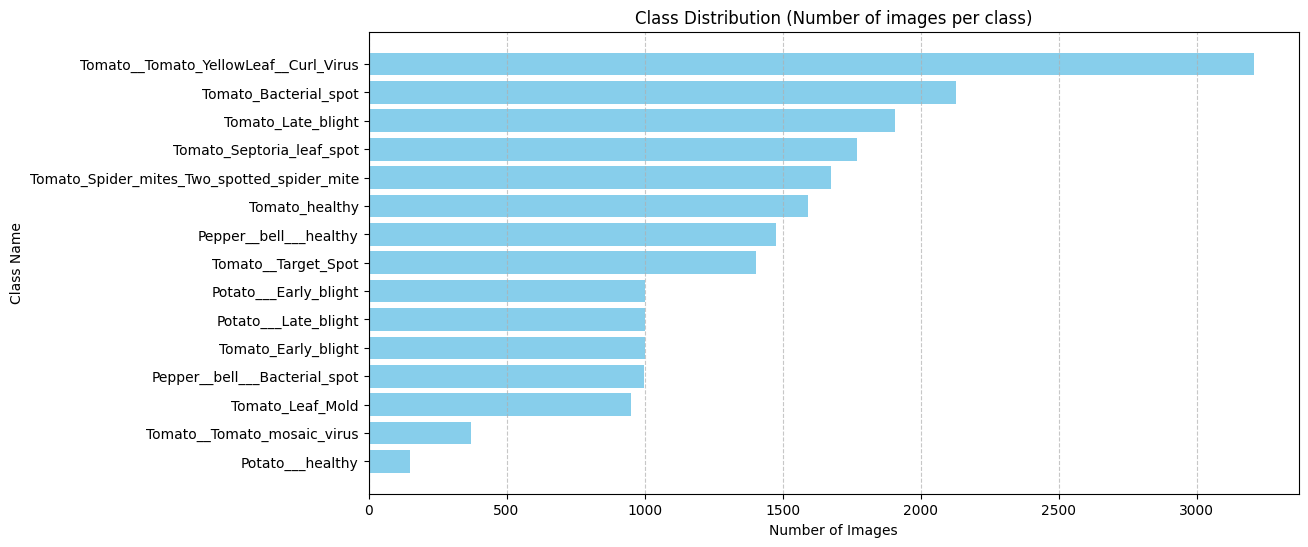

In [ ]:
data = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data.append({'Class': class_name, 'Count': count})

df_dist = pd.DataFrame(data).sort_values(by='Count', ascending=False)

print("Image distribution across classes:")
print(df_dist.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(df_dist['Class'], df_dist['Count'], color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.title('Class Distribution (Number of images per class)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Classes Number: 15


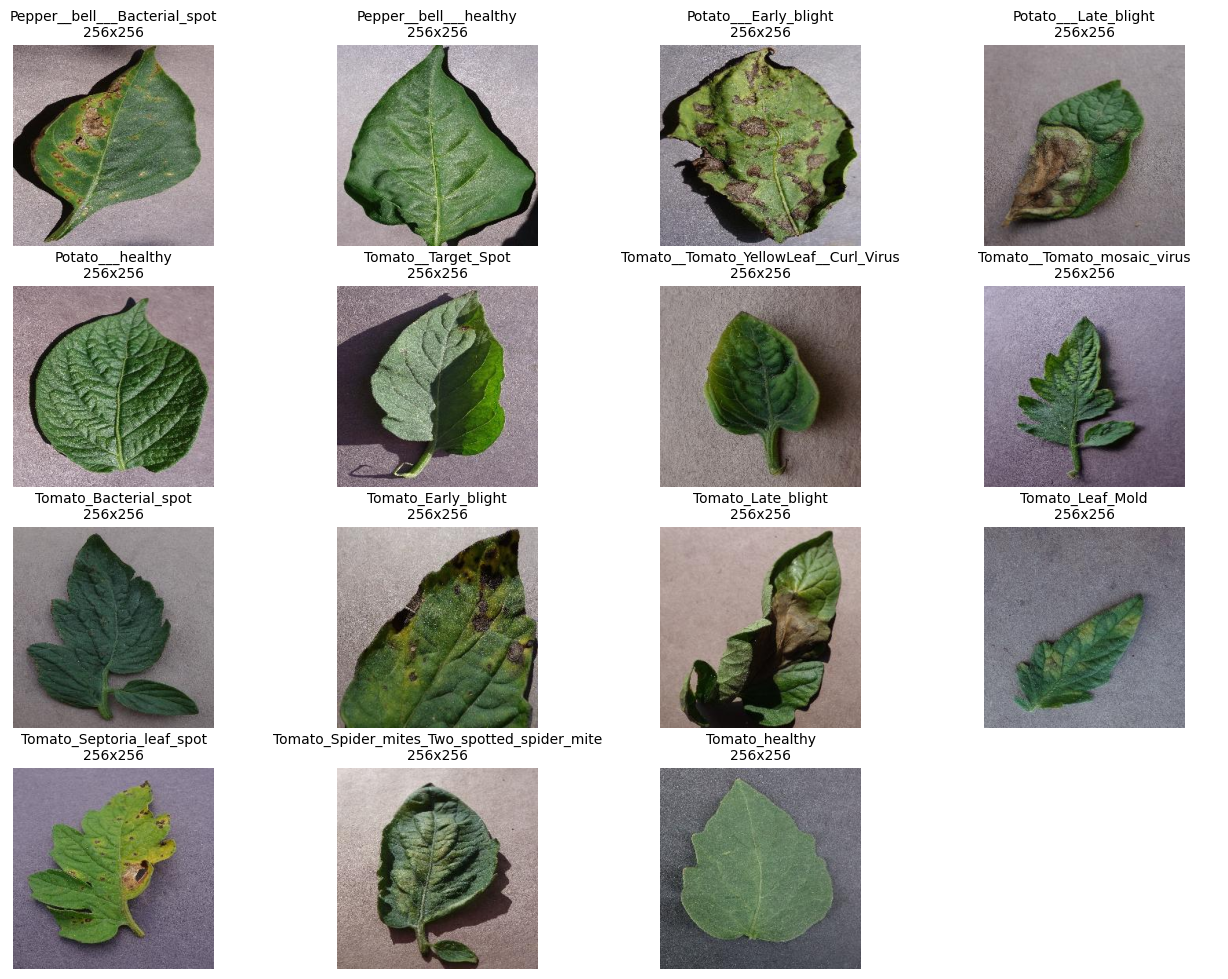

In [ ]:
def VisualizeClasses(folders_path):
    # Get all class folders and sort them
    ClassesNames = os.listdir(folders_path)
    ClassesNames.sort(key=lambda x: (x.split('__')[0], x))

    # Display the total number of classes
    NUM_CLASSES = len(ClassesNames)
    print(f"Classes Number: {NUM_CLASSES}")

    cols = 4
    rows = (NUM_CLASSES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()

    # Show one sample image from each class
    for i, cat in enumerate(ClassesNames):
        ClassFolderPath = os.path.join(folders_path,cat)
        ImagesName = os.listdir(ClassFolderPath)
        img_path = os.path.join(ClassFolderPath,ImagesName[0])
        with Image.open(img_path) as img:
            width, height = img.size
        image = mpimg.imread(img_path)
        axes[i].imshow(image)
        axes[i].set_title(f"{cat}\n{width}x{height}", fontsize=10)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

VisualizeClasses(IMAGES_FOLDERS_PATH)

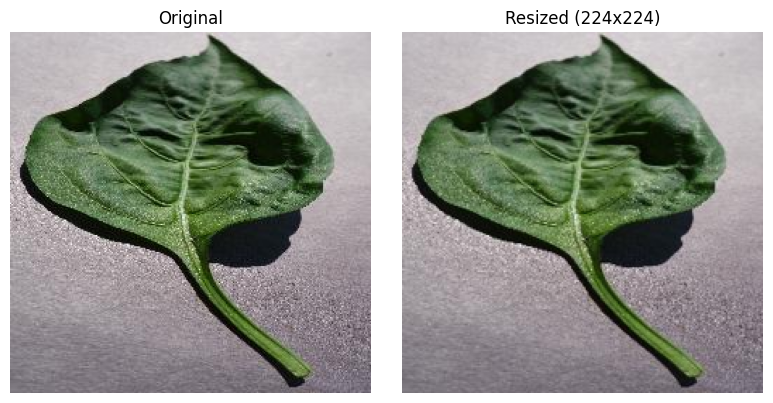

In [ ]:
# Pick a random class folder
ClassesNames = os.listdir(IMAGES_FOLDERS_PATH)
random_class = random.choice(ClassesNames)
class_path = os.path.join(IMAGES_FOLDERS_PATH, random_class)

# Pick a random image from that class
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

# Open and resize the selected image to 224x224
with Image.open(img_path) as img:
    resized_img = img.resize((WIDTH, HEIGHT))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized ({WIDTH}x{HEIGHT})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

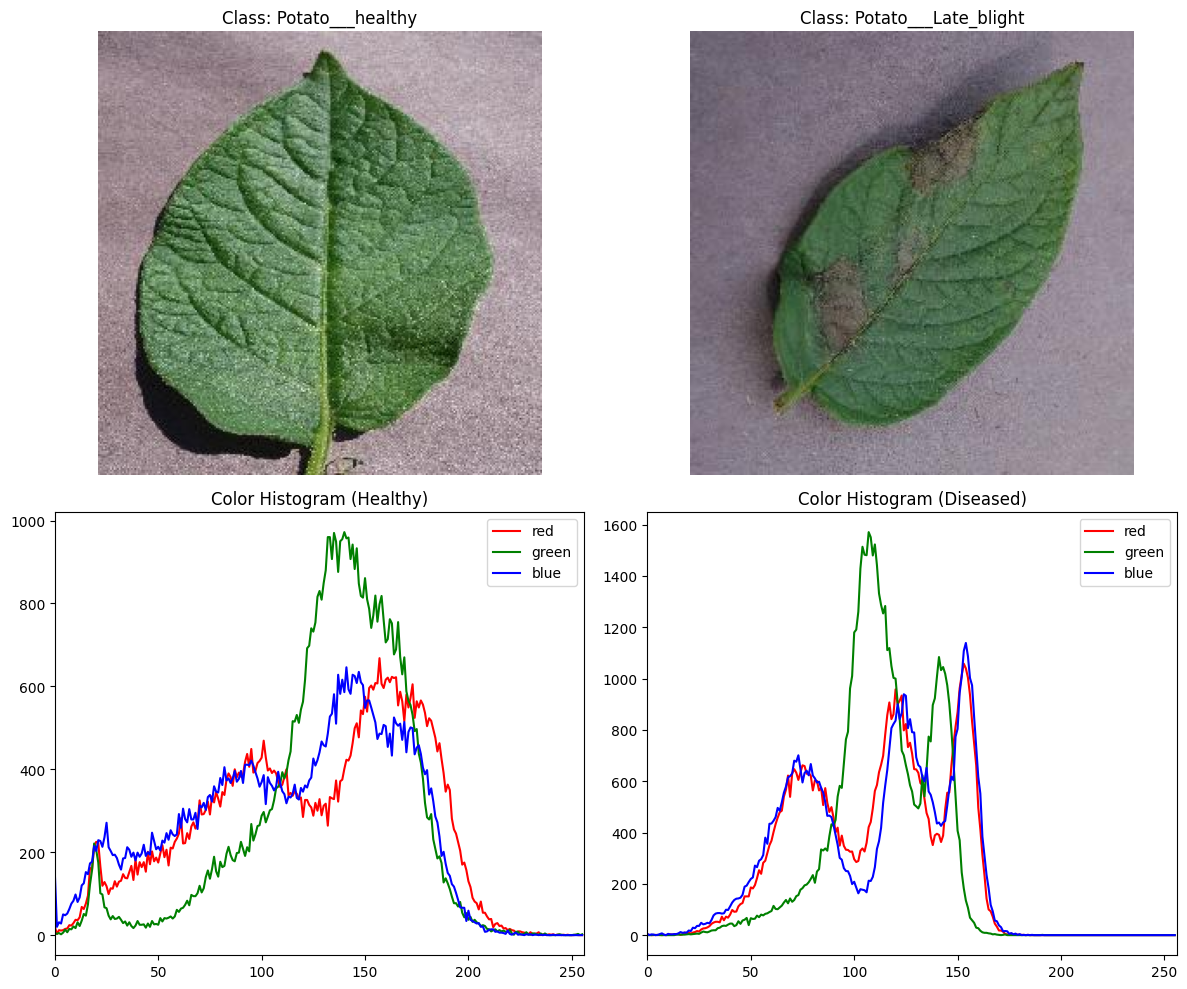

In [ ]:
def plot_healthy_vs_diseased(plant_name):
    all_classes = [d for d in os.listdir(IMAGES_FOLDERS_PATH) if d.startswith(plant_name)]

    healthy_class = [c for c in all_classes if 'healthy' in c.lower()]
    diseased_classes = [c for c in all_classes if 'healthy' not in c.lower()]

    if not healthy_class or not diseased_classes:
        print(f"Couldn't find both healthy and diseased for {plant_name}")
        return

    target_diseased = random.choice(diseased_classes)
    target_healthy = healthy_class[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for i, class_name in enumerate([target_healthy, target_diseased]):
        class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Class: {class_name}")
        axes[0, i].axis('off')

        colors = ('red', 'green', 'blue')
        for j, col in enumerate(colors):
            hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
            axes[1, i].plot(hist, color=col, label=col)
            axes[1, i].set_xlim([0, 256])

        axes[1, i].set_title(f"Color Histogram ({'Healthy' if i==0 else 'Diseased'})")
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

plot_healthy_vs_diseased('Potato')

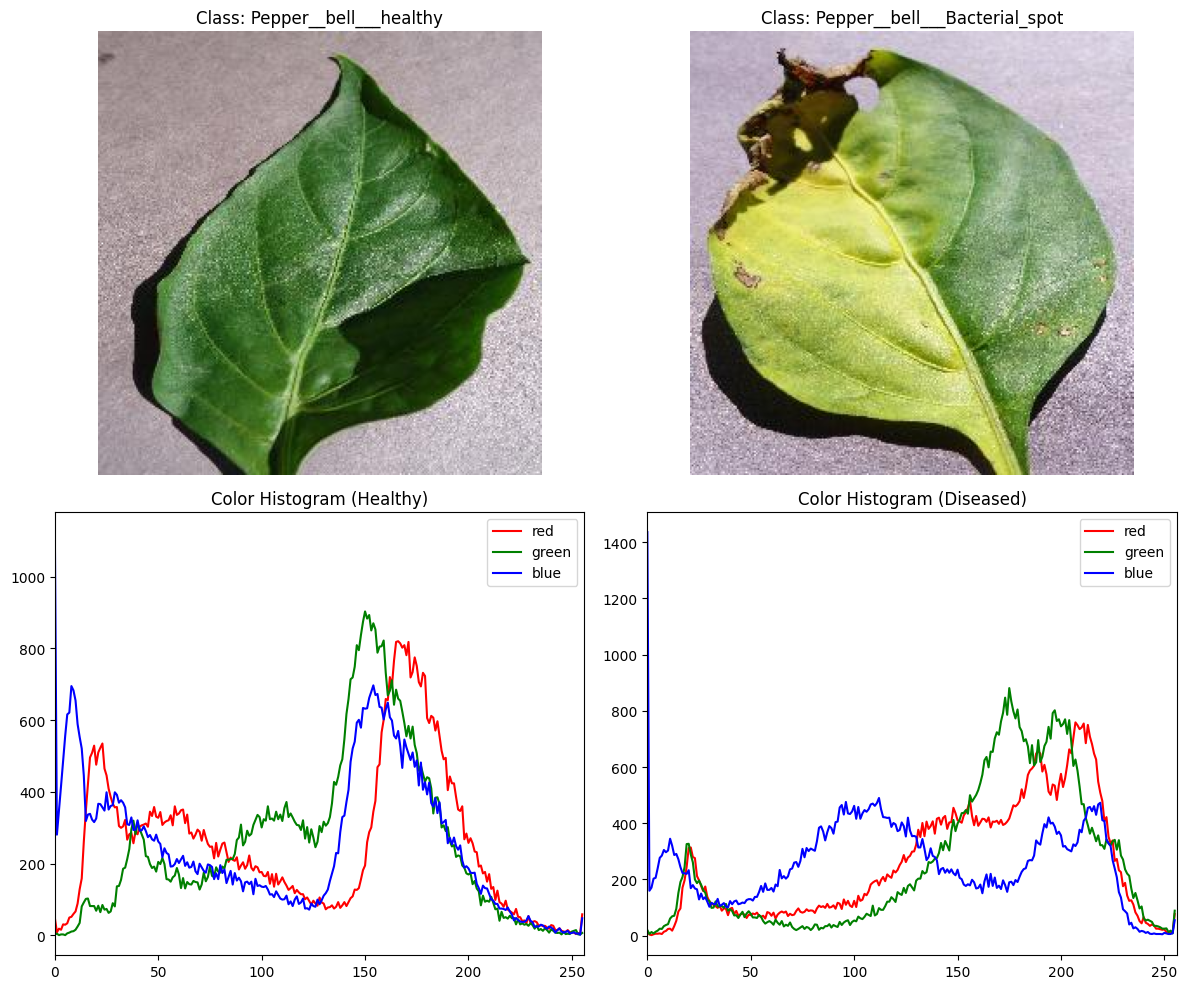

In [ ]:
plot_healthy_vs_diseased('Pepper')

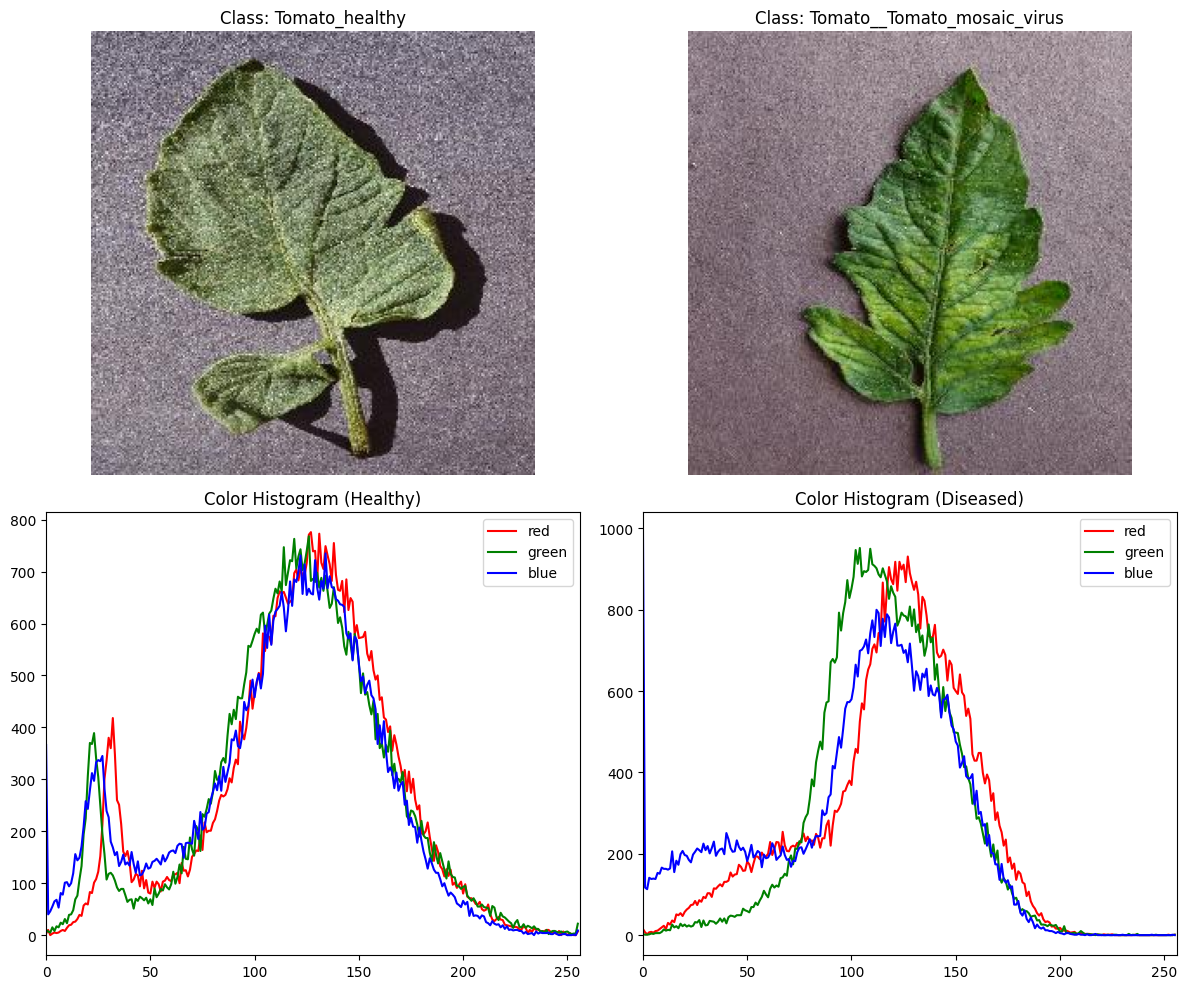

In [ ]:
plot_healthy_vs_diseased('Tomato')

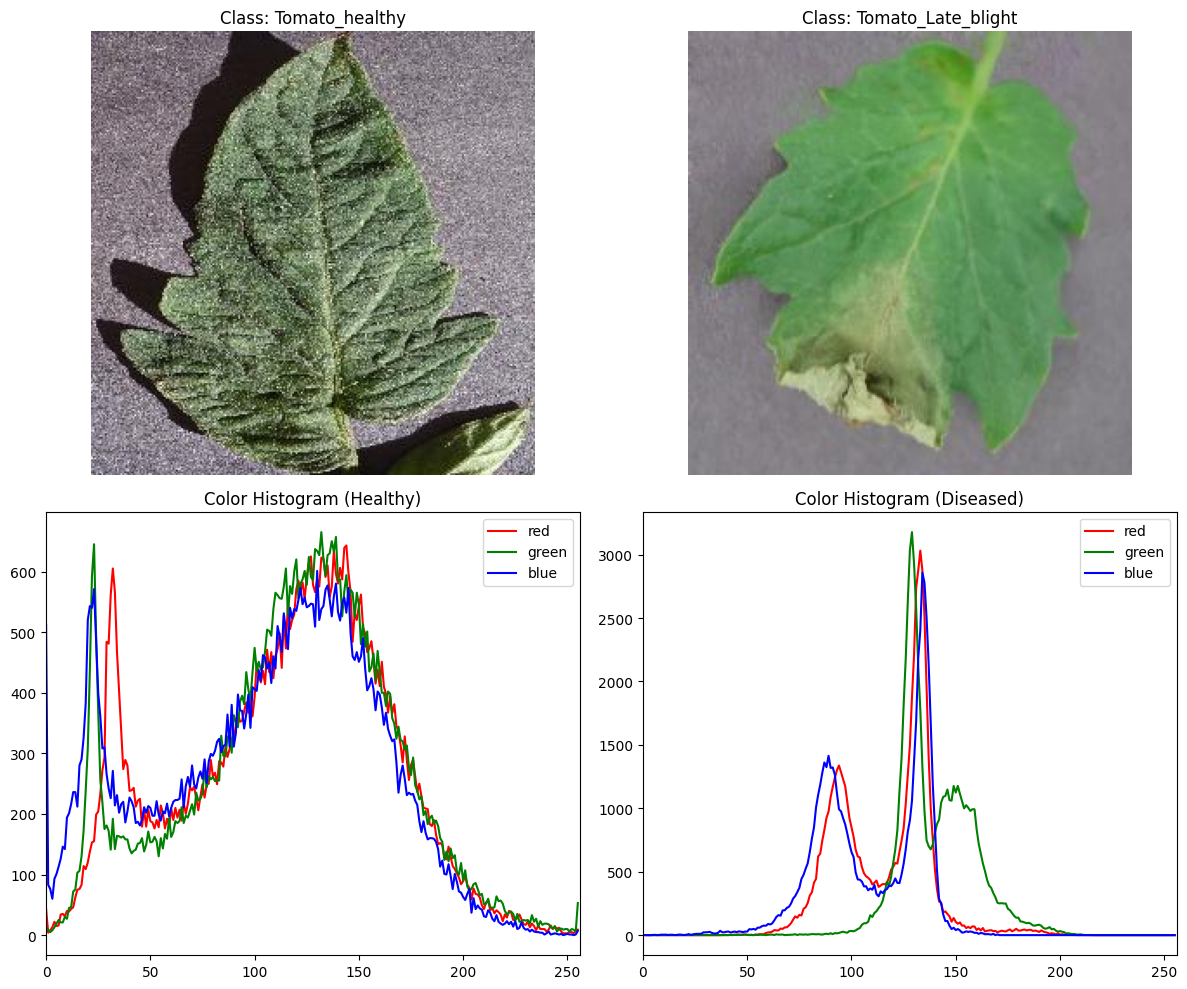

In [ ]:
plot_healthy_vs_diseased('Tomato')

In [ ]:
splitfolders.ratio(IMAGES_FOLDERS_PATH, output=OUTPUT_FOLDER, seed=42, ratio=(0.8, 0.2))

Copying files: 20639 files [03:53, 88.34 files/s] 


In [ ]:
def compute_color_histogram(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hist_features = []
    for i in range(3):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)
    return hist_features

def compute_texture_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (WIDTH, HEIGHT))

    lbp = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, LBP_METHOD)
    n_bins = LBP_N_POINTS + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                                range=(0, n_bins), density=True)

    gray_small = (gray // 4).astype(np.uint8)
    levels = 64
    glcm   = np.zeros((levels, levels), dtype=np.float64)
    glcm[gray_small[:, :-1].ravel(),
         gray_small[:, 1: ].ravel()] += 1
    glcm += glcm.T
    glcm /= glcm.sum()

    i, j  = np.mgrid[0:levels, 0:levels]
    mu    = (i * glcm).sum()
    denom = np.sqrt((glcm * (i - mu)**2).sum()) * \
            np.sqrt((glcm * (j - mu)**2).sum())

    contrast    = (glcm * (i - j)**2).sum()
    energy      = (glcm**2).sum()
    homogeneity = (glcm / (1.0 + (i - j)**2)).sum()
    correlation = (glcm * (i - mu) * (j - mu)).sum() / (denom + 1e-10)

    return list(lbp_hist) + [contrast, energy, homogeneity, correlation]


In [ ]:
all_images = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        all_images.append((class_name, os.path.join(class_path, img_name)))

print(f"Total images: {len(all_images)}")

Total images: 20639


In [ ]:
data = []

for class_name, img_path in tqdm(all_images, desc="Extracting features"):
    color_features   = compute_color_histogram(img_path)
    texture_features = compute_texture_features(img_path)

    if color_features is None or texture_features is None:
        continue

    final_features = color_features + texture_features
    data.append({'class': class_name, 'features': final_features})

df = pd.DataFrame(data)
df.to_pickle('features.pkl')

print(f"Number of Images: {len(df)}")
print(df.head())

Extracting features: 100%|███████████████████████████████████████████████████████| 20639/20639 [13:07<00:00, 26.22it/s]


Number of Images: 20638
                           class  \
0  Pepper__bell___Bacterial_spot   
1  Pepper__bell___Bacterial_spot   
2  Pepper__bell___Bacterial_spot   
3  Pepper__bell___Bacterial_spot   
4  Pepper__bell___Bacterial_spot   

                                            features  
0  [0.002189968, 0.00273746, 0.0007299893, 0.0040...  
1  [0.048521336, 0.016173778, 0.019526878, 0.0205...  
2  [0.0100539485, 0.004928406, 0.0043369974, 0.00...  
3  [0.025218707, 0.0075030862, 0.0060441527, 0.00...  
4  [0.0629117, 0.01174857, 0.016106911, 0.0170543...  


In [ ]:
df = pd.read_pickle('features.pkl')
X = np.stack(df['features'].values)
y = df['class'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=40, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}\n")

Original number of features: 798
Number of features after PCA: 40



In [ ]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
knn_preds = knn.predict(X_test_pca)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")


nb = GaussianNB()
nb.fit(X_train_pca, y_train)
nb_preds = nb.predict(X_test_pca)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds) * 100:.2f}%")

KNN Accuracy: 81.13%
Naive Bayes Accuracy: 52.45%


##   Bagging Algorithms

In [ ]:
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
acc_rf = accuracy_score(y_test,y_pred_rf)
print(f"RandomForest Accuracy: { acc_rf*100:.2f}%")

RandomForest Accuracy: 85.73%


In [ ]:
base_classifier = DecisionTreeClassifier()
#bagging
bagging_classifier = BaggingClassifier(base_classifier ,n_estimators=10,random_state=42)
bagging_classifier.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [ ]:
y_pred = bagging_classifier.predict(X_test)
acc_bagging = accuracy_score(y_test,y_pred)
print(f"Bagging Accuracy:{acc_bagging *100:.2f}%")

Bagging Accuracy:80.16%


## Boosting algorthim(adaboost)

In [ ]:
ada = AdaBoostClassifier( estimator=base_classifier,n_estimators=300,learning_rate=0.1 , random_state=42)
ada.fit(X_train ,y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test , y_pred_ada)
print(f"AdaBoost Accuracy: {acc_ada*100:.2f}%")

AdaBoost Accuracy: 65.87%


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_params = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1,2]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=cv, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_pca, y_train)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best KNN CV Accuracy:", knn_grid.best_score_)

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best KNN CV Accuracy: 0.8290732889158086


C:\Users\ahmed\anaconda3\envs\plant_disease\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.8029679  0.81084191 0.8029679  0.81084191 0.80714718 0.8128407
 0.80714718 0.8128407  0.80345245 0.80884313 0.80345245 0.80884313
 0.8007874  0.80629921 0.8007874  0.80629921 0.79672925 0.80187765
 0.79672925 0.80187765 0.78606905 0.79339794 0.78606905 0.79339794
        nan 0.82574197        nan 0.82574197        nan 0.82907329
        nan 0.82907329        nan 0.82713507        nan 0.82713507
        nan 0.82531799        nan 0.82531799        nan 0.82016959
        nan 0.82016959        nan 0.81332526        nan 0.81332526
        nan 0.82574197 0.8029679  0.81084191        nan 0.82907329
 0.80714718 0.8128407         nan 0.82713507 0.80345245 0.80884313
        nan 0.82531799 0.8007874  0.80629921        nan 0.82016959
 0.79672925 0.80187765        nan 0.81332526 0.78606905 0.79339794]
  warnings.warn(


In [ ]:
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'criterion': ['entropy']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced',oob_score=True),
    rf_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_pca, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF CV Accuracy:", rf_grid.best_score_)

Best RF Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV Accuracy: 0.8317989097516657


In [ ]:
bagging_params = {
    'n_estimators': [50, 100],
    'max_samples': [0.8, 1.0],
    'max_features': [0.8, 1.0]
}

bagging_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'), random_state=42),
    bagging_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

bagging_grid.fit(X_train_pca, y_train)

print(f"Best Bagging Params: {bagging_grid.best_params_}")
print(f"Best Bagging CV Accuracy: {bagging_grid.best_score_:.4f}")

Best Bagging Params: {'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 100}
Best Bagging CV Accuracy: 0.8216


In [ ]:
ada_params = {
    'n_estimators': [50, 150],
    'learning_rate': [0.1, 0.5]
}

وأدق بكتير من 1
base_est = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_est, random_state=42),
    ada_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

ada_grid.fit(X_train_pca, y_train)

print(f"Best AdaBoost Params: {ada_grid.best_params_}")
print(f"Best AdaBoost CV Accuracy: {ada_grid.best_score_:.4f}")

Best AdaBoost Params: {'learning_rate': 0.5, 'n_estimators': 150}
Best AdaBoost CV Accuracy: 0.7414


## AutoEncoders

load data

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

Data engineering

In [ ]:
autoencoder_data = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
#filter healthy images from dataset
healthy_data = []
#resize the images
img_size = 128

print("Starting to load healthy images...")
for folder in os.listdir(autoencoder_data):
    if 'healthy' in folder.lower():
        folder_path = os.path.join(autoencoder_data, folder)

        for img_name in os.listdir(folder_path):
            try:
                img_path = os.path.join(folder_path, img_name)
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (img_size, img_size))

                healthy_data.append(image)
            except Exception as e:
                pass

print(f"Done! Loaded {len(healthy_data)} healthy images.")

Starting to load healthy images...
Done! Loaded 3221 healthy images.


In [ ]:
healthy_data = np.array(healthy_data, dtype='float32')
#Normalization
healthy_data = healthy_data / 255.0
print(f"Data shape: {healthy_data.shape}")
#split
x_train, x_val = train_test_split(healthy_data, test_size=0.2, random_state=42)
print(f"Training set: {x_train.shape}")
print(f"Validation set: {x_val.shape}")

Data shape: (3221, 128, 128, 3)
Training set: (2576, 128, 128, 3)
Validation set: (645, 128, 128, 3)


Model Archeticture

In [ ]:
input_shape = (128, 128, 3)
model = models.Sequential([
    #encoder
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    #Decoder
    layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same'),

    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])
#autoencoder
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 128, 128, 32)   │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,939 (54.45 KB)

 Trainable params: 13,939 (54.45 KB)

 Non-trainable params: 0 (0.00 B)

Training phase

In [ ]:
epochsNum = 50
batchSize = 32

history = model.fit(x_train, x_train,epochs=epochsNum,batch_size=batchSize,
    validation_data=(x_val, x_val),  shuffle=True
)

Epoch 1/50


I0000 00:00:1776502683.983807     304 service.cc:152] XLA service 0x7a3188048600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776502683.983881     304 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776502683.983887     304 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776502684.461907     304 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-18 08:58:06.832026: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 08:58:07.108945: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 08:58:07.601214: E external/local_xl

 7/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0336

I0000 00:00:1776502689.828932     304 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0303

2026-04-18 08:58:13.262755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 08:58:13.400891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - loss: 0.0301 - val_loss: 0.0170
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0162 - val_loss: 0.0139
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0129 - val_loss: 0.0112
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0095 - val_loss: 0.0083
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0084 - val_loss: 0.0079
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0076 - val_loss: 0.0076
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0069 - val_loss: 0.0071
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0069 - val_loss: 0.0069
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0063 - val_

output

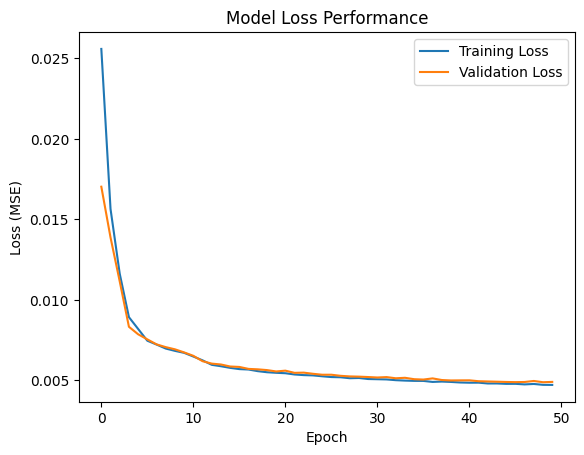

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Performance')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Transfer learning

In [ ]:
results = {
    'Model': ['KNN', 'Random Forest', 'Bagging', 'AdaBoost'],
    'Best CV Accuracy': [
        knn_grid.best_score_,
        rf_grid.best_score_,
        bagging_grid.best_score_,
        ada_grid.best_score_
    ]
}
df_results = pd.DataFrame(results).sort_values(by='Best CV Accuracy', ascending=False)

print("--- 1. Models Comparison (Validation Phase) ---")
print(df_results)
print("\n" + "="*50 + "\n")


final_model = rf_grid.best_estimator_
y_pred = final_model.predict(X_test_pca)

print("--- 2. Final Evaluation (Best Model: Random Forest) ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- 1. Models Comparison (Validation Phase) ---
           Model  Best CV Accuracy
1  Random Forest          0.831799
0            KNN          0.829073
2        Bagging          0.821623
3       AdaBoost          0.741429


--- 2. Final Evaluation (Best Model: Random Forest) ---
Final Test Accuracy: 0.8394

Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.79      0.83      0.81       199
                     Pepper__bell___healthy       0.81      0.82      0.82       296
                      Potato___Early_blight       0.87      0.89      0.88       200
                       Potato___Late_blight       0.78      0.71      0.74       200
                           Potato___healthy       0.87      0.43      0.58        30
                      Tomato_Bacterial_spot       0.85      0.85      0.85       426
                        Tomato_Early_blight       0.85      0.

In [ ]:
import splitfolders

splitfolders.ratio(
    "/content/drive/MyDrive/Project_SP/PlantVillage",
    output="/content/drive/MyDrive/Project_SP/plantdisease_split",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 20655 files [11:31, 29.88 files/s]


In [ ]:
train_path = "/content/drive/MyDrive/Project_SP/plantdisease_split/train"
val_path   = "/content/drive/MyDrive/Project_SP/plantdisease_split/val"
test_path  = "/content/drive/MyDrive/Project_SP/plantdisease_split/test"

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32
)

Found 14451 files belonging to 15 classes.
Found 3092 files belonging to 15 classes.
Found 3111 files belonging to 15 classes.


In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

In [ ]:
base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_mobilenet.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_mobilenet = tf.keras.Sequential([
    base_mobilenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 121s 215ms/step - accuracy: 0.7549 - loss: 0.7759 - val_accuracy: 0.8776 - val_loss: 0.3796
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.8689 - loss: 0.4003 - val_accuracy: 0.8896 - val_loss: 0.3272
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 156ms/step - accuracy: 0.8910 - loss: 0.3220 - val_accuracy: 0.9000 - val_loss: 0.3211
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 155ms/step - accuracy: 0.9111 - loss: 0.2607 - val_accuracy: 0.9149 - val_loss: 0.2665
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 155ms/step - accuracy: 0.9235 - loss: 0.2224 - val_accuracy: 0.9155 - val_loss: 0.2586
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 79s 174ms/step - accuracy: 0.9348 - loss: 0.1980 - val_accuracy: 0.9178 - val_loss: 0.2438
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.9390 - loss: 0.1775 - val_accuracy: 0.9246 - val_loss: 0.2283
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 157ms/step - accuracy: 0.9426 - loss: 

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_e = train_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)).prefetch(AUTOTUNE)
val_ds_e   = val_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)).prefetch(AUTOTUNE)
test_ds_e  = test_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)).prefetch(AUTOTUNE)

In [ ]:
base_efficientnet = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_efficientnet.trainable = False

In [ ]:
model_efficientnet = tf.keras.Sequential([
    base_efficientnet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_efficientnet = model_efficientnet.fit(
    train_ds_e,
    validation_data=val_ds_e,
    epochs=10
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 126s 210ms/step - accuracy: 0.1444 - loss: 2.5944 - val_accuracy: 0.1557 - val_loss: 2.5712
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 72s 160ms/step - accuracy: 0.1485 - loss: 2.5848 - val_accuracy: 0.1557 - val_loss: 2.5702
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 73s 161ms/step - accuracy: 0.1492 - loss: 2.5816 - val_accuracy: 0.1557 - val_loss: 2.5704
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 72s 159ms/step - accuracy: 0.1512 - loss: 2.5797 - val_accuracy: 0.1557 - val_loss: 2.5697
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 72s 159ms/step - accuracy: 0.1499 - loss: 2.5802 - val_accuracy: 0.1557 - val_loss: 2.5679
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 73s 161ms/step - accuracy: 0.1534 - loss: 2.5803 - val_accuracy: 0.1557 - val_loss: 2.5671
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 73s 161ms/step - accuracy: 0.1529 - loss: 2.5802 - val_accuracy: 0.1557 - val_loss: 2.5684
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 72s 160ms/step - accuracy: 0.1539 - loss: 

In [ ]:
mobilenet_acc = model_mobilenet.evaluate(test_ds)[1]
efficientnet_acc = model_efficientnet.evaluate(test_ds)[1]

print("MobileNet Accuracy:", mobilenet_acc)
print("EfficientNet Accuracy:", efficientnet_acc)

98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9260 - loss: 0.2218
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - accuracy: 0.1550 - loss: 2.5709
MobileNet Accuracy: 0.9260212182998657
EfficientNet Accuracy: 0.15503376722335815


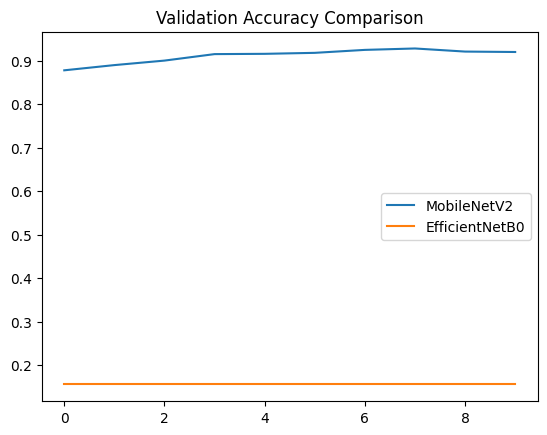

In [ ]:
plt.plot(history_mobilenet.history['val_accuracy'])
plt.plot(history_efficientnet.history['val_accuracy'])

plt.title("Validation Accuracy Comparison")
plt.legend(['MobileNetV2', 'EfficientNetB0'])
plt.show()

In [ ]:
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")

In [ ]:
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [ ]:
def build_fresh_model(optimizer_obj, model_name):
    """Creates a fresh MobileNetV2 transfer learning model."""
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # Freeze the backbone

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(len(class_names), activation='softmax')
    ], name=model_name)

    model.compile(
        optimizer=optimizer_obj,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
optimizers_to_test = {
    'Adam': tf.keras.optimizers.Adam(learning_rate=1e-4),
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=1e-4)
}

history_dict = {}
test_results = {}

for name, opt in optimizers_to_test.items():
    print(f"\n--- Training with {name} ---")
    current_model = build_fresh_model(opt, f"Model_{name}")

    history = current_model.fit(
        train_ds_aug,
        validation_data=val_ds,
        epochs=10,
        verbose=1
    )

    history_dict[name] = history.history
    loss, acc = current_model.evaluate(test_ds, verbose=0)
    test_results[name] = acc


--- Training with Adam ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 261s 536ms/step - accuracy: 0.3203 - loss: 2.1814 - val_accuracy: 0.3370 - val_loss: 2.0420
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 251s 554ms/step - accuracy: 0.4576 - loss: 1.7290 - val_accuracy: 0.3820 - val_loss: 1.8762
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 216s 476ms/step - accuracy: 0.5049 - loss: 1.5518 - val_accuracy: 0.3994 - val_loss: 1.8255
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 221s 489ms/step - accuracy: 0.5352 - loss: 1.4431 - val_accuracy: 0.3968 - val_loss: 1.8230
Epoch 5/10
  7/452 ━━━━━━━━━━━━━━━━━━━━ 3:08 423ms/step - accuracy: 0.5356 - loss: 1.3330

In [ ]:
history_rmsprop = run_optimizer_experiment("RMSprop", tf.keras.optimizers.RMSprop(learning_rate=1e-4))


Starting Experiment: RMSprop
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 273s 533ms/step - accuracy: 0.5127 - loss: 1.6830 - val_accuracy: 0.6963 - val_loss: 1.1234
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 477ms/step - accuracy: 0.7205 - loss: 0.9675 - val_accuracy: 0.7814 - val_loss: 0.7757
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 215s 475ms/step - accuracy: 0.7751 - loss: 0.7445 - val_accuracy: 0.8079 - val_loss: 0.6362
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 216s 477ms/step - accuracy: 0.8135 - loss: 0.6174 - val_accuracy: 0.8435 - val_loss: 0.5394
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 256s 565ms/step - accuracy: 0.8316 - loss: 0.5494 - val_accuracy: 0.8551 - val_loss: 0.4873
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 220s 486ms/step - accuracy: 0.8451 - loss: 0.4987 - val_accuracy: 0.8638 - val_loss: 0.4513
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 220s 486ms/step - accuracy: 0.8584 - loss: 0.4539 - val_accuracy: 0.8758 - val_loss: 0.4140
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 260s 4

In [ ]:
history_sgd = run_optimizer_experiment("SGD_Momentum", tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9))


Starting Experiment: SGD_Momentum
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 271s 533ms/step - accuracy: 0.4523 - loss: 1.8275 - val_accuracy: 0.6646 - val_loss: 1.2404
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 219s 484ms/step - accuracy: 0.6810 - loss: 1.0860 - val_accuracy: 0.7409 - val_loss: 0.9102
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 479ms/step - accuracy: 0.7370 - loss: 0.8632 - val_accuracy: 0.7707 - val_loss: 0.7538
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 478ms/step - accuracy: 0.7697 - loss: 0.7407 - val_accuracy: 0.7998 - val_loss: 0.6631
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 311s 588ms/step - accuracy: 0.7934 - loss: 0.6678 - val_accuracy: 0.8118 - val_loss: 0.5999
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 228s 503ms/step - accuracy: 0.8071 - loss: 0.6110 - val_accuracy: 0.8299 - val_loss: 0.5436
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 220s 486ms/step - accuracy: 0.8215 - loss: 0.5700 - val_accuracy: 0.8334 - val_loss: 0.5259
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

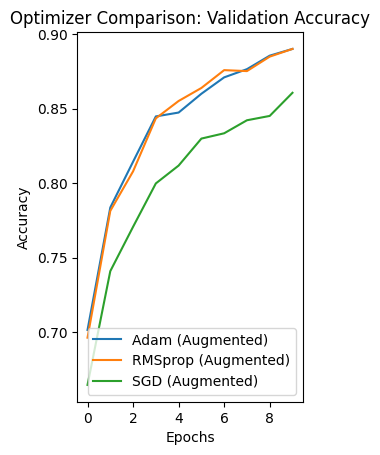

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['val_accuracy'], label='Adam (Augmented)')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop (Augmented)')
plt.plot(history_sgd.history['val_accuracy'], label='SGD (Augmented)')
plt.title('Optimizer Comparison: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

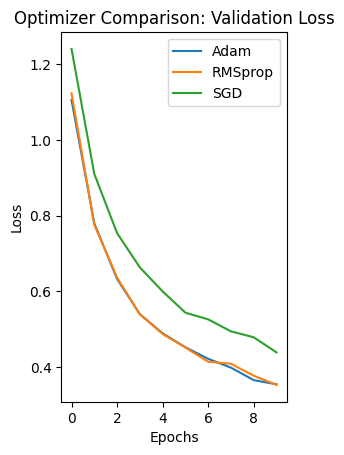

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_rmsprop.history['val_loss'], label='RMSprop')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.title('Optimizer Comparison: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Text(0.5, 0.98, 'Your Task: Examples of Data Augmentation applied to a single leaf')

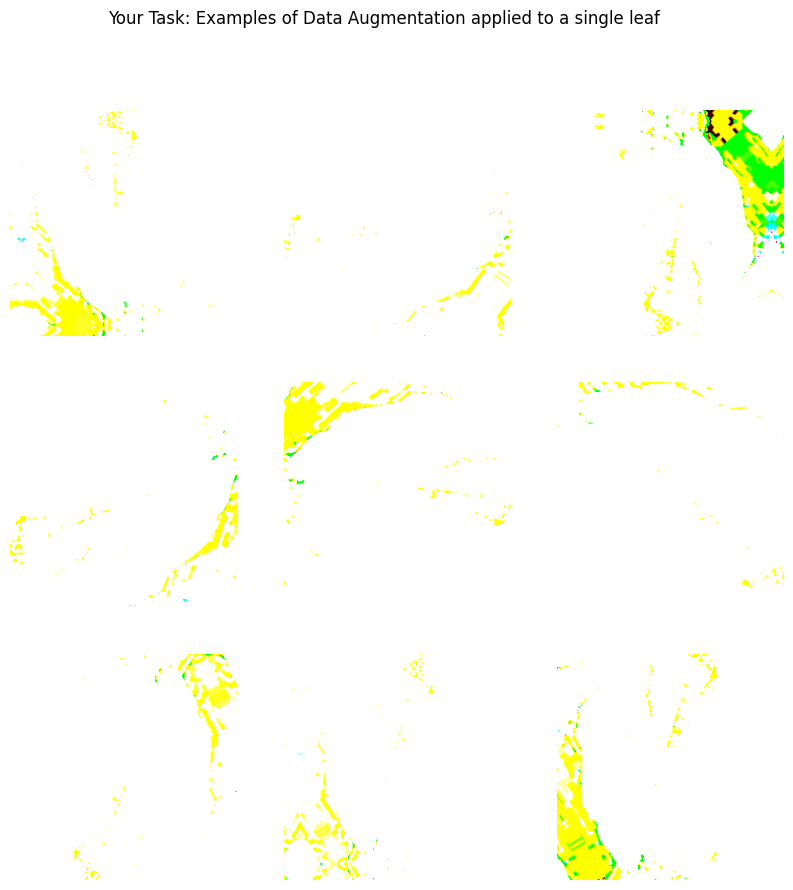

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy())
        plt.axis("off")
plt.suptitle("Your Task: Examples of Data Augmentation applied to a single leaf")

## GRU

In [10]:
BATCH_SIZE = 32
LEARNING_RATE = 0.001
MAX_EPOCHS = 20
RANDOM_SEED = 42

IMG_H, IMG_W = HEIGHT, WIDTH
INPUT_FEATURES = IMG_W * CHANNELS
OUTPUT_FOLDER = '/content/drive/MyDrive/Project_SP/plantdisease_split'
if not os.path.exists(OUTPUT_FOLDER):
    splitfolders.ratio(
        IMAGES_FOLDERS_PATH,
        output=OUTPUT_FOLDER,
        seed=RANDOM_SEED,
        ratio=(0.70, 0.15, 0.15)
    )
    print("Dataset split successfully.")
else:
    print("Folders already exist, proceeding to data loading...")

base_train_path = os.path.join(OUTPUT_FOLDER, 'train')
base_val_path   = os.path.join(OUTPUT_FOLDER, 'val')
base_test_path  = os.path.join(OUTPUT_FOLDER, 'test')

categories = sorted(os.listdir(base_train_path))
num_categories = len(categories)

Folders already exist, proceeding to data loading...


In [11]:
class PlantDataStreamer(tf.keras.utils.Sequence):
    def __init__(self, src_dir, category_list, batch_size=32,
                 target_size=(224, 224), use_augmentation=False, do_shuffle=True):
        self.src_dir = src_dir
        self.category_list = category_list
        self.batch_size = batch_size
        self.target_size = target_size
        self.use_augmentation = use_augmentation
        self.do_shuffle = do_shuffle

        self.all_files = []
        self.all_labels = []

        for label, cat in enumerate(category_list):
            cat_path = os.path.join(src_dir, cat)
            if not os.path.isdir(cat_path): continue
            for f in os.listdir(cat_path):
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.all_files.append(os.path.join(cat_path, f))
                    self.all_labels.append(label)

        self.indices = np.arange(len(self.all_files))
        if self.do_shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.all_files) / self.batch_size))

    def _process_img(self, img_path):
        bgr_img = cv2.imread(img_path)
        rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
        resized_img = cv2.resize(rgb_img, (self.target_size[1], self.target_size[0]))

        final_img = resized_img.astype('float32') / 255.0

        if self.use_augmentation:
            if random.random() > 0.5:
                final_img = np.fliplr(final_img)
            brightness_lvl = random.uniform(0.9, 1.1)
            final_img = np.clip(final_img * brightness_lvl, 0, 1)

        return final_img.reshape(self.target_size[0], -1)

    def __getitem__(self, idx):
        batch_map = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        x_data = np.array([self._process_img(self.all_files[i]) for i in batch_map])
        y_data = tf.keras.utils.to_categorical([self.all_labels[i] for i in batch_map], num_categories)
        return x_data, y_data

    def on_epoch_end(self):
        if self.do_shuffle:
            np.random.shuffle(self.indices)

train_loader = PlantDataStreamer(base_train_path, categories, BATCH_SIZE, use_augmentation=True)
val_loader   = PlantDataStreamer(base_val_path, categories, BATCH_SIZE)
test_loader  = PlantDataStreamer(base_test_path, categories, BATCH_SIZE, do_shuffle=False)

In [12]:
from tensorflow.keras import layers, models, optimizers, callbacks
def create_gru_classifier(steps, features, classes, learning_rate=0.001):
    model_input = layers.Input(shape=(steps, features))

    net = layers.GRU(256, return_sequences=True, dropout=0.2)(model_input)
    net = layers.BatchNormalization()(net)

    net = layers.GRU(128, return_sequences=False, dropout=0.2)(net)
    net = layers.BatchNormalization()(net)

    net = layers.Dense(128, activation='relu')(net)
    net = layers.Dropout(0.4)(net)

    model_output = layers.Dense(classes, activation='softmax')(net)

    model = models.Model(inputs=model_input, outputs=model_output, name="Plant_GRU_Model")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

gru_net = create_gru_classifier(IMG_H, INPUT_FEATURES, num_categories, LEARNING_RATE)
gru_net.summary()

Model: "Plant_GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 672)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 224, 256)       │       714,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,447 (3.37 MB)

 Trainable params: 881,679 (3.36 MB)

 Non-trainable params: 768 (3.00 KB)

In [13]:
training_callbacks = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
    callbacks.ModelCheckpoint('plant_gru_weights.h5', save_best_only=True, monitor='val_accuracy')
]

In [14]:
history = gru_net.fit(
    train_loader,
    validation_data=val_loader,
    epochs=MAX_EPOCHS,
    callbacks=training_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2191 - loss: 2.5371

452/452 ━━━━━━━━━━━━━━━━━━━━ 4834s 11s/step - accuracy: 0.3003 - loss: 2.2250 - val_accuracy: 0.3613 - val_loss: 2.1539 - learning_rate: 0.0010
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 897s 2s/step - accuracy: 0.4606 - loss: 1.7002 - val_accuracy: 0.2759 - val_loss: 2.5459 - learning_rate: 0.0010
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5068 - loss: 1.5300

452/452 ━━━━━━━━━━━━━━━━━━━━ 938s 2s/step - accuracy: 0.5232 - loss: 1.4893 - val_accuracy: 0.5298 - val_loss: 1.3938 - learning_rate: 0.0010
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5499 - loss: 1.3779

452/452 ━━━━━━━━━━━━━━━━━━━━ 929s 2s/step - accuracy: 0.5587 - loss: 1.3659 - val_accuracy: 0.5747 - val_loss: 1.2725 - learning_rate: 0.0010
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 879s 2s/step - accuracy: 0.5865 - loss: 1.2758 - val_accuracy: 0.5120 - val_loss: 1.4788 - learning_rate: 0.0010
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 878s 2s/step - accuracy: 0.6103 - loss: 1.2020 - val_accuracy: 0.5689 - val_loss: 1.2454 - learning_rate: 0.0010
Epoch 7/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 885s 2s/step - accuracy: 0.6247 - loss: 1.1402 - val_accuracy: 0.5537 - val_loss: 1.3164 - learning_rate: 0.0010
Epoch 8/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6378 - loss: 1.0990

452/452 ━━━━━━━━━━━━━━━━━━━━ 876s 2s/step - accuracy: 0.6450 - loss: 1.0872 - val_accuracy: 0.5844 - val_loss: 1.2805 - learning_rate: 0.0010
Epoch 9/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6509 - loss: 1.0625

452/452 ━━━━━━━━━━━━━━━━━━━━ 879s 2s/step - accuracy: 0.6566 - loss: 1.0525 - val_accuracy: 0.6391 - val_loss: 1.0939 - learning_rate: 0.0010
Epoch 10/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 917s 2s/step - accuracy: 0.6698 - loss: 1.0126 - val_accuracy: 0.4706 - val_loss: 1.5772 - learning_rate: 0.0010
Epoch 11/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6795 - loss: 0.9711

452/452 ━━━━━━━━━━━━━━━━━━━━ 923s 2s/step - accuracy: 0.6823 - loss: 0.9624 - val_accuracy: 0.6902 - val_loss: 0.9489 - learning_rate: 0.0010
Epoch 12/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 868s 2s/step - accuracy: 0.6948 - loss: 0.9235 - val_accuracy: 0.5899 - val_loss: 1.2790 - learning_rate: 0.0010
Epoch 13/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7021 - loss: 0.9145

452/452 ━━━━━━━━━━━━━━━━━━━━ 895s 2s/step - accuracy: 0.7024 - loss: 0.9122 - val_accuracy: 0.7571 - val_loss: 0.7241 - learning_rate: 0.0010
Epoch 14/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 868s 2s/step - accuracy: 0.7179 - loss: 0.8664 - val_accuracy: 0.7083 - val_loss: 0.8776 - learning_rate: 0.0010
Epoch 15/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 898s 2s/step - accuracy: 0.7209 - loss: 0.8456 - val_accuracy: 0.7264 - val_loss: 0.8241 - learning_rate: 0.0010
Epoch 16/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 902s 2s/step - accuracy: 0.7219 - loss: 0.8374 - val_accuracy: 0.1514 - val_loss: 6.5454 - learning_rate: 0.0010
Epoch 17/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 854s 2s/step - accuracy: 0.7356 - loss: 0.8076 - val_accuracy: 0.1559 - val_loss: 7.2020 - learning_rate: 0.0010
Epoch 18/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7638 - loss: 0.7049

452/452 ━━━━━━━━━━━━━━━━━━━━ 875s 2s/step - accuracy: 0.7691 - loss: 0.6928 - val_accuracy: 0.8351 - val_loss: 0.4894 - learning_rate: 2.0000e-04
Epoch 19/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7889 - loss: 0.6591

452/452 ━━━━━━━━━━━━━━━━━━━━ 849s 2s/step - accuracy: 0.7838 - loss: 0.6651 - val_accuracy: 0.8389 - val_loss: 0.4754 - learning_rate: 2.0000e-04
Epoch 20/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7859 - loss: 0.6449

452/452 ━━━━━━━━━━━━━━━━━━━━ 857s 2s/step - accuracy: 0.7847 - loss: 0.6468 - val_accuracy: 0.8470 - val_loss: 0.4541 - learning_rate: 2.0000e-04


In [15]:
gru_net.load_weights('plant_gru_weights.h5')
test_loss, test_acc = gru_net.evaluate(test_loader)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

98/98 ━━━━━━━━━━━━━━━━━━━━ 810s 8s/step - accuracy: 0.8566 - loss: 0.4239

Final Test Accuracy: 85.66%


In [16]:
actual_labels = []
predicted_labels = []

for i in tqdm(range(len(test_loader)), desc="Generating Predictions"):
    imgs, lbls = test_loader[i]
    raw_preds = gru_net.predict(imgs, verbose=0)
    actual_labels.extend(np.argmax(lbls, axis=1))
    predicted_labels.extend(np.argmax(raw_preds, axis=1))

Generating Predictions: 100%|██████████| 98/98 [01:31<00:00,  1.07it/s]


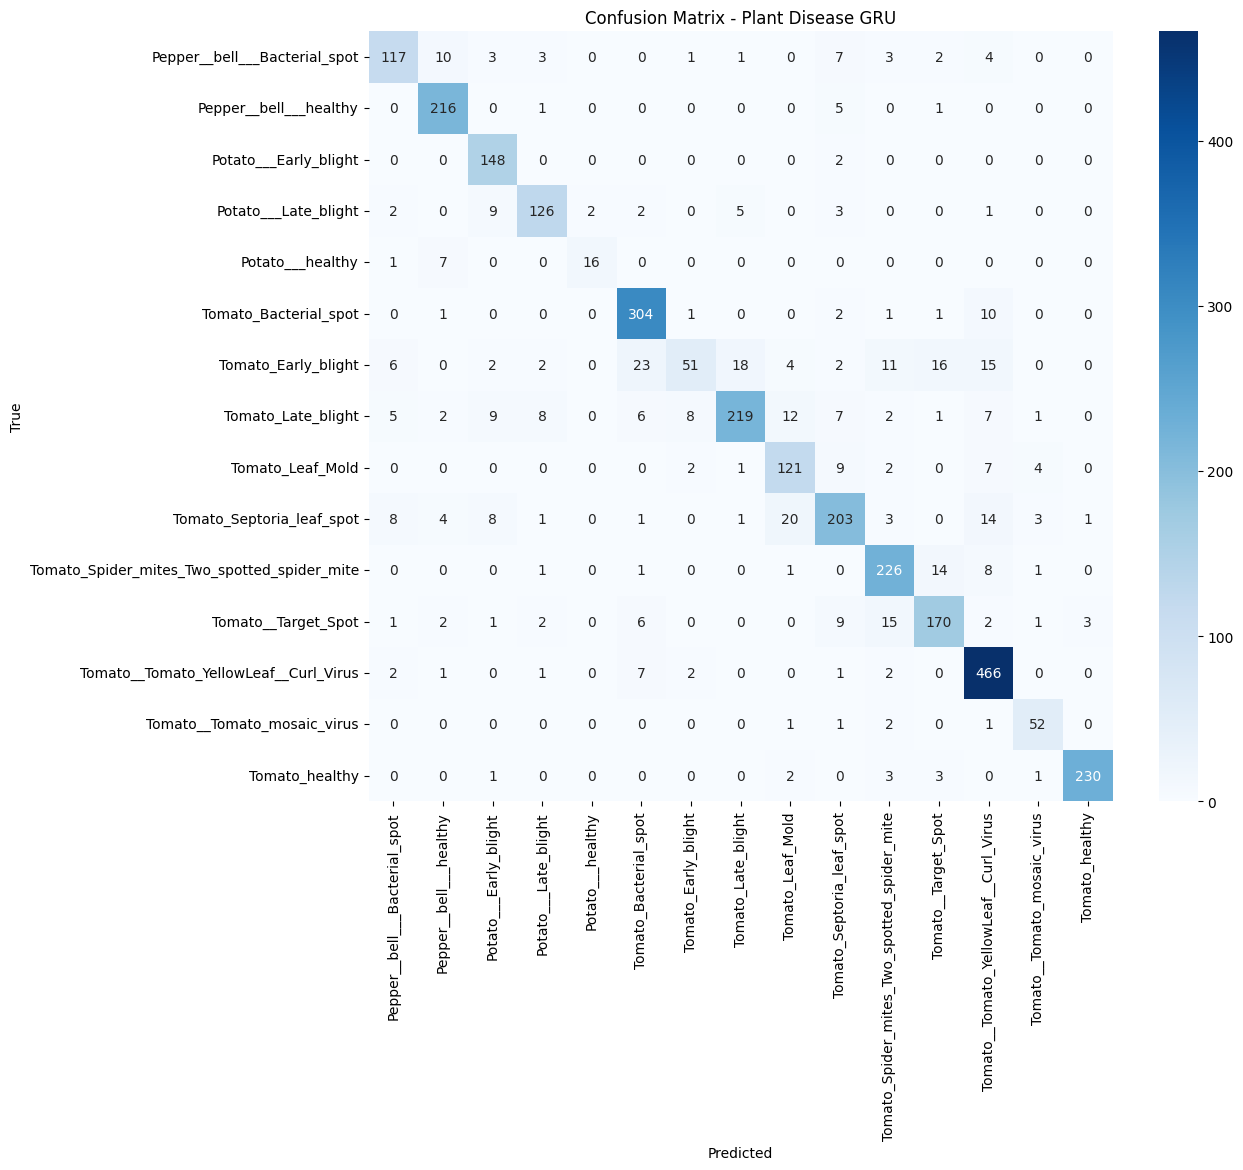

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
conf_mtx = confusion_matrix(actual_labels, predicted_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix - Plant Disease GRU')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [20]:
final_report = classification_report(actual_labels, predicted_labels, target_names=categories)
print(final_report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.82      0.77      0.80       151
                     Pepper__bell___healthy       0.89      0.97      0.93       223
                      Potato___Early_blight       0.82      0.99      0.89       150
                       Potato___Late_blight       0.87      0.84      0.85       150
                           Potato___healthy       0.89      0.67      0.76        24
                      Tomato_Bacterial_spot       0.87      0.95      0.91       320
                        Tomato_Early_blight       0.78      0.34      0.47       150
                         Tomato_Late_blight       0.89      0.76      0.82       287
                           Tomato_Leaf_Mold       0.75      0.83      0.79       146
                  Tomato_Septoria_leaf_spot       0.81      0.76      0.78       267
Tomato_Spider_mites_Two_spotted_spider_mite       0.84      0.90